## Agenda

1. Feature Scaling
2. Optimal Cluster Selection (Elbow Method)
3. K-Means Clustering Implementation
4. Cluster Visualization (Scatter Plot)
5. Network Technology Distribution
6. Model Evaluation (Silhouette Score)

## Environment Setup and Imports

The required libraries are imported to support data loading, feature scaling, K-Means clustering, cluster analysis, and visualization.

K-Means is used as an unsupervised learning method to identify groups of network observations with similar signal strength, throughput, and latency characteristics.

In [16]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


## Load the Prepared Dataset

The cleaned dataset generated during the preprocessing stage is loaded for the clustering analysis.

The dataset is inspected to verify its dimensions and available features before selecting the variables used by K-Means.

In [17]:
data_path = "../data/processed/processed_data.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

print("\nAvailable columns:")
print(df.columns.tolist())

print("\nFirst five observations:")
print(df.head())

Dataset shape: (16829, 7)

Available columns:
['Locality', 'Latitude', 'Longitude', 'Signal Strength (dBm)', 'Data Throughput (Mbps)', 'Latency (ms)', 'Network Type']

First five observations:
            Locality   Latitude  Longitude  Signal Strength (dBm)  \
0           Anisabad  25.599109  85.137355             -84.274113   
1        Fraser Road  25.433286  85.070053             -97.653121   
2  Boring Canal Road  25.498809  85.211371             -87.046134   
3            Danapur  25.735138  85.208400             -94.143159   
4    Phulwari Sharif  25.538556  85.159860             -94.564765   

   Data Throughput (Mbps)  Latency (ms) Network Type  
0                1.863890    129.122914           3G  
1                5.132296     54.883606           4G  
2                1.176985    119.598286           4G  
3               68.596932     46.598387           5G  
4               38.292038     30.342828           5G  


## Select Clustering Features

Three numerical network performance features are selected for clustering: signal strength, data throughput, and latency.

These variables represent complementary aspects of network behavior and provide a meaningful basis for identifying distinct network performance groups.

In [18]:
clustering_features = [
    "Signal Strength (dBm)",
    "Data Throughput (Mbps)",
    "Latency (ms)"
]

features = df[clustering_features].copy()

print("Selected clustering features:")
print(clustering_features)

print("\nFeature matrix shape:", features.shape)

print("\nFeature summary:")
print(features.describe())

Selected clustering features:
['Signal Strength (dBm)', 'Data Throughput (Mbps)', 'Latency (ms)']

Feature matrix shape: (16829, 3)

Feature summary:
       Signal Strength (dBm)  Data Throughput (Mbps)  Latency (ms)
count           16829.000000            16829.000000  16829.000000
mean              -90.072484               16.182856    101.313624
std                 5.399368               25.702734     56.010418
min              -116.942267                1.000423     10.019527
25%               -93.615962                2.001749     50.320775
50%               -89.665566                2.997175    100.264318
75%               -86.145491                9.956314    149.951112
max               -74.644848               99.985831    199.991081


## Standardize Clustering Features

The selected clustering features are standardized using StandardScaler before applying K-Means.

Standardization ensures that the features contribute to the distance calculations on a comparable scale, preventing variables with larger numerical ranges from dominating the clustering process.

In [19]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Scaled feature matrix shape:", scaled_features.shape)

print("\nFirst five scaled observations:")
print(scaled_features[:5])

Scaled feature matrix shape: (16829, 3)

First five scaled observations:
[[ 1.07392997 -0.55711548  0.49651684]
 [-1.40402749 -0.42994988 -0.82897788]
 [ 0.56051754 -0.58384125  0.32646079]
 [-0.75393911  2.03930188 -0.97690509]
 [-0.83202576  0.86021353 -1.26713757]]


## Determine the Number of Clusters Using the Elbow Method

The Elbow Method is applied to evaluate different numbers of clusters.

For each value of k, the K-Means inertia is calculated. Inertia measures the sum of squared distances between observations and their assigned cluster centroids.

The resulting curve is used to identify a suitable number of clusters for the network segmentation task.

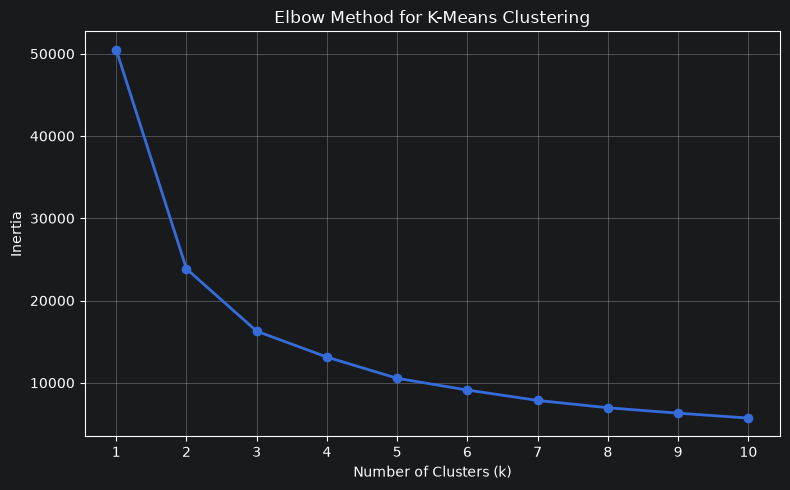

In [5]:
inertia = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    inertia,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")

plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

## Build the Final K-Means Model

Based on the Elbow Method, three clusters are selected as a suitable configuration for the network segmentation task.

The final K-Means model is fitted using the standardized network performance features.

In [6]:
optimal_k = 3

kmeans_model = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(
    scaled_features
)

df["Cluster"] = cluster_labels

print("K-Means model trained successfully.")
print(f"Number of clusters: {optimal_k}")

print("\nCluster distribution:")
print(df["Cluster"].value_counts().sort_index())

K-Means model trained successfully.
Number of clusters: 3

Cluster distribution:
Cluster
0    7375
1    3342
2    6112
Name: count, dtype: int64


## Profile the Network Clusters

The resulting clusters are profiled using the mean values of the selected network performance features.

This analysis helps interpret the characteristics of each cluster and identify different network performance patterns.

In [7]:
cluster_summary = (
    df.groupby("Cluster")[clustering_features]
    .mean()
    .round(2)
)

print("Average Network Characteristics by Cluster:")
print(cluster_summary)

Average Network Characteristics by Cluster:
         Signal Strength (dBm)  Data Throughput (Mbps)  Latency (ms)
Cluster                                                             
0                       -86.47                    2.12        153.21
1                       -95.82                   62.98         29.61
2                       -91.27                    7.56         77.90


## Visualize Network Performance Clusters

The identified network clusters are visualized using signal strength and data throughput.

The visualization provides a two-dimensional view of the segmentation and highlights the differences between the discovered network performance groups.

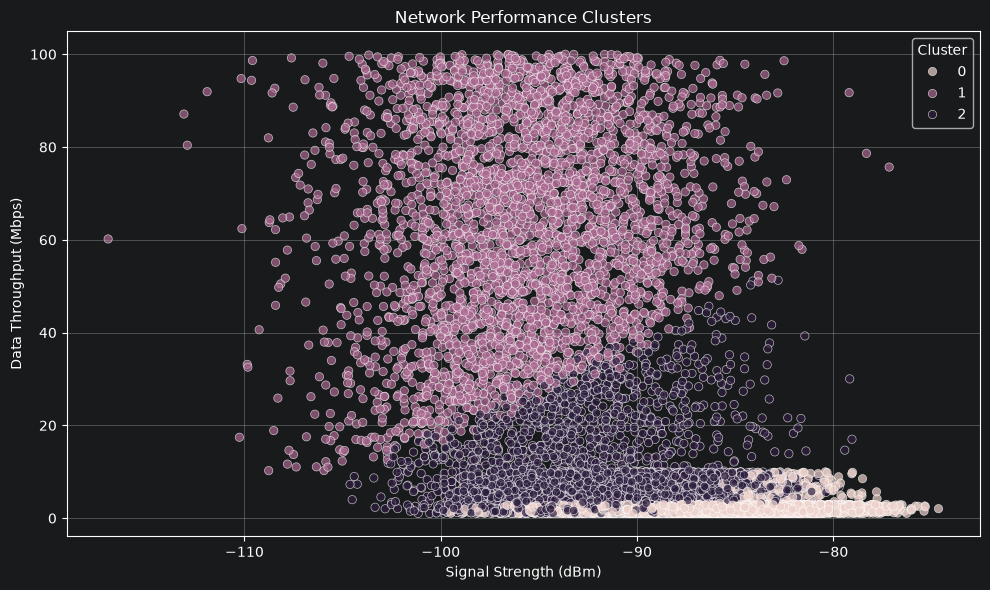

In [8]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Signal Strength (dBm)",
    y="Data Throughput (Mbps)",
    hue="Cluster",
    alpha=0.7
)

plt.title("Network Performance Clusters")
plt.xlabel("Signal Strength (dBm)")
plt.ylabel("Data Throughput (Mbps)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Assign Interpretable Cluster Labels

The numerical cluster identifiers are mapped to descriptive performance categories based on the average throughput and latency observed within each cluster.

The original cluster IDs are preserved while the descriptive labels improve interpretability for analysis and deployment.

In [9]:
cluster_labels_map = {
    0: "Low Performance",
    1: "High Performance",
    2: "Moderate Performance"
}

df["Performance Level"] = df["Cluster"].map(
    cluster_labels_map
)

print(
    df[
        ["Cluster", "Performance Level"]
    ].drop_duplicates().sort_values("Cluster")
)

print("\nPerformance Level Distribution:")
print(
    df["Performance Level"]
    .value_counts()
)

   Cluster     Performance Level
0        0       Low Performance
3        1      High Performance
1        2  Moderate Performance

Performance Level Distribution:
Performance Level
Low Performance         7375
Moderate Performance    6112
High Performance        3342
Name: count, dtype: int64


## Build the K-Means Deployment Pipeline

A deployment pipeline is created to combine feature standardization with the trained K-Means model.

The pipeline ensures that new observations receive the same preprocessing transformation before cluster assignment, maintaining consistency between training and deployment.

In [10]:
kmeans_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "kmeans",
            KMeans(
                n_clusters=optimal_k,
                random_state=42,
                n_init=10
            )
        )
    ]
)

kmeans_pipeline.fit(features)

print("K-Means deployment pipeline trained successfully.")

K-Means deployment pipeline trained successfully.


## Verify the K-Means Deployment Pipeline

The deployment pipeline is verified by generating cluster assignments for the prepared observations.

The resulting cluster distribution is compared with the previously generated clustering results to confirm that the pipeline performs the expected transformations and clustering process.

In [11]:
pipeline_clusters = kmeans_pipeline.predict(features)

print("Cluster assignments generated:", pipeline_clusters.shape)

print("\nCluster distribution:")
print(
    pd.Series(pipeline_clusters)
    .value_counts()
    .sort_index()
)

print(
    "\nNumber of unique clusters:",
    len(np.unique(pipeline_clusters))
)

Cluster assignments generated: (16829,)

Cluster distribution:
0    7375
1    3342
2    6112
Name: count, dtype: int64

Number of unique clusters: 3


## Analyze Network Technology Distribution Across Clusters

The distribution of network technologies is analyzed within each performance cluster.

This analysis helps determine whether 3G, 4G, and 5G observations are concentrated within specific network performance groups.

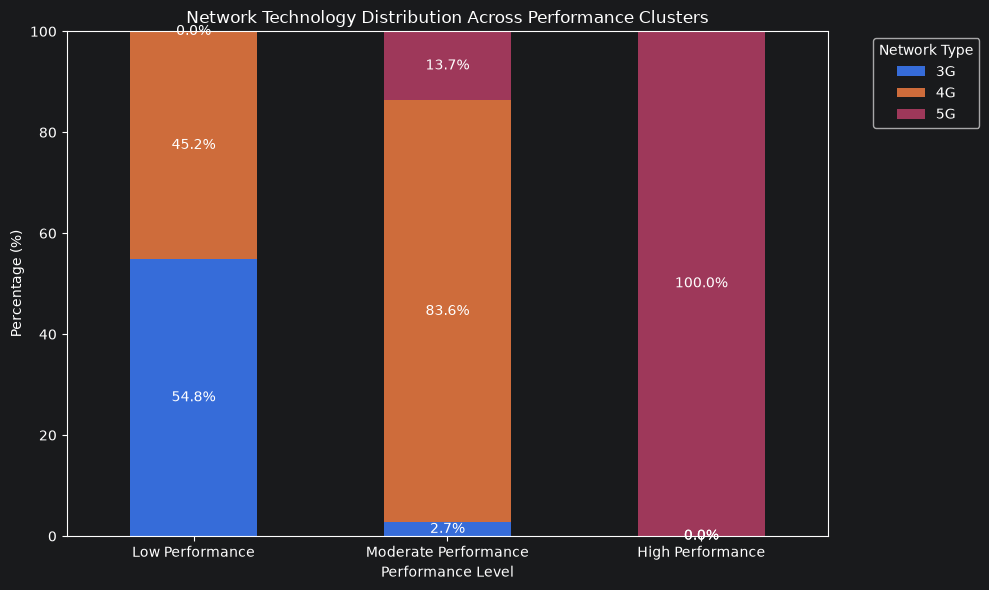

In [12]:
technology_distribution = pd.crosstab(
    df["Performance Level"],
    df["Network Type"],
    normalize="index"
) * 100

cluster_order = [
    "Low Performance",
    "Moderate Performance",
    "High Performance"
]

technology_distribution = technology_distribution.reindex(
    cluster_order
)

ax = technology_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Network Technology Distribution Across Performance Clusters")
plt.xlabel("Performance Level")
plt.ylabel("Percentage (%)")
plt.legend(
    title="Network Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",
        fmt="%.1f%%"
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Analyze Cluster Distribution

The distribution of observations across the identified performance clusters is analyzed to understand the relative size of each network performance group.

In [13]:
cluster_distribution = (
    df["Performance Level"]
    .value_counts()
    .reindex(cluster_order)
)

print("Cluster Distribution:")
print(cluster_distribution)

print("\nCluster Distribution (%):")
print(
    (cluster_distribution / len(df) * 100)
    .round(2)
)

Cluster Distribution:
Performance Level
Low Performance         7375
Moderate Performance    6112
High Performance        3342
Name: count, dtype: int64

Cluster Distribution (%):
Performance Level
Low Performance         43.82
Moderate Performance    36.32
High Performance        19.86
Name: count, dtype: float64


## Validate Deployment Consistency

The deployment pipeline is validated against the cluster assignments generated during model development to ensure consistent clustering behavior before deployment.

In [14]:
pipeline_clusters = kmeans_pipeline.predict(features)

consistency_check = np.array_equal(
    cluster_labels,
    pipeline_clusters
)

print("Cluster assignment consistency:", consistency_check)

if consistency_check:
    print("The deployment pipeline produces the same cluster assignments.")
else:
    print("Warning: Cluster assignments differ between development and deployment.")

Cluster assignment consistency: True
The deployment pipeline produces the same cluster assignments.


## Save the Deployment Pipeline

The validated K-Means pipeline is saved as a reusable model artifact so that the same preprocessing and clustering logic can be applied consistently during deployment.

In [15]:
model_path = "../models/kmeans.joblib"

joblib.dump(
    kmeans_pipeline,
    model_path
)

print(f"K-Means pipeline saved successfully to: {model_path}")

K-Means pipeline saved successfully to: ../models/kmeans.joblib
